# 5 Results Analysis

This notebook analyses the validated AI transparency scores for the final sample of 20 firms.

The analysis includes:

- final transparency rankings
- descriptive statistics
- score distribution
- comparison of original and manually adjusted scores
- changes in company ranking following manual validation
- transparency-level classification, and
- preparation of results tables and visualisations for the dissertation.

In [1]:
# Importing libraries and define project paths

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Main project folders
data_folder = Path("../data")
outputs_folder = Path("../outputs")
evidence_folder = outputs_folder / "evidence_tables"
figures_folder = outputs_folder / "figures"
results_folder = outputs_folder / "results"

# Creating folders for new outputs if they do not already exist
figures_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

# Input files
manual_review_file = data_folder / "manual_review_notes.csv"
final_ranking_file = evidence_folder / "final_transparency_ranking.csv"

print("Manual review file:", manual_review_file)
print("Final ranking file:", final_ranking_file)
print("Figures folder:", figures_folder)
print("Results folder:", results_folder)

Manual review file: ..\data\manual_review_notes.csv
Final ranking file: ..\outputs\evidence_tables\final_transparency_ranking.csv
Figures folder: ..\outputs\figures
Results folder: ..\outputs\results


In [2]:
# Confirming that the required input files exist

required_files = {
    "Manual review notes": manual_review_file,
    "Final transparency ranking": final_ranking_file,
}

for file_name, file_path in required_files.items():
    if file_path.exists():
        print(f"✓ {file_name} found: {file_path}")
    else:
        print(f"✗ {file_name} not found: {file_path}")

✓ Manual review notes found: ..\data\manual_review_notes.csv
✓ Final transparency ranking found: ..\outputs\evidence_tables\final_transparency_ranking.csv


## 1. Loading and validating the final data

In [3]:
# Manually reviewed data and final ranking

manual_review = pd.read_csv(
    manual_review_file,
    dtype={"company_id": str}
)

final_ranking = pd.read_csv(
    final_ranking_file,
    dtype={"company_id": str}
)

# Preserving the three-digit company ID format
manual_review["company_id"] = manual_review["company_id"].str.zfill(3)
final_ranking["company_id"] = final_ranking["company_id"].str.zfill(3)

print("Manual review rows:", len(manual_review))
print("Final ranking rows:", len(final_ranking))

print("\nManual review columns:")
print(manual_review.columns.tolist())

print("\nFinal ranking columns:")
print(final_ranking.columns.tolist())

Manual review rows: 20
Final ranking rows: 20

Manual review columns:
['company_id', 'company_name', 'total_ai_transparency_mentions', 'unique_keywords', 'unique_pages', 'total_score', 'score_percentage', 'manual_adjusted_score', 'manual_adjusted_percentage', 'reason_for_adjustment', 'important_pages', 'important_extracts', 'review_status']

Final ranking columns:
['final_rank', 'original_rank', 'company_id', 'company_name', 'total_score', 'final_score', 'score_change', 'score_percentage', 'final_score_percentage', 'rank_change']


In [4]:
# Displaying the manually validated transparency ranking

final_ranking

,final_rank,original_rank,company_id,company_name,total_score,final_score,score_change,score_percentage,final_score_percentage,rank_change
0,1,1,004,NatWest Group plc,13,13.0,0.0,92.86,92.86,0
1,2,2,001,Barclays plc,12,12.0,0.0,85.71,85.71,0
2,2,4,002,HSBC Holdings plc,9,12.0,3.0,64.29,85.71,2
3,2,4,003,Lloyds Banking Group plc,9,12.0,3.0,64.29,85.71,2
4,2,4,005,Standard Chartered plc,9,12.0,3.0,64.29,85.71,2
5,3,3,009,Admiral Group plc,11,11.0,0.0,78.57,78.57,0
6,3,6,020,Experian plc,7,11.0,4.0,50.00,78.57,3
7,3,5,019,London Stock Exchange Group plc,8,11.0,3.0,57.14,78.57,2
8,4,7,006,Aviva plc,6,10.0,4.0,42.86,71.43,3
9,5,4,016,Funding Circle Holdings plc,9,9.0,0.0,64.29,64.29,-1


In [5]:
# Conducting basic data-quality checks

key_columns = [
    "company_id",
    "company_name",
    "final_score",
    "final_score_percentage",
]

print("Duplicate company IDs:",
      final_ranking["company_id"].duplicated().sum())

print("\nMissing values in key columns:")
print(final_ranking[key_columns].isna().sum())

print("\nFinal score range:")
print(
    final_ranking["final_score"].min(),
    "to",
    final_ranking["final_score"].max()
)

print("\nFinal percentage range:")
print(
    final_ranking["final_score_percentage"].min(),
    "to",
    final_ranking["final_score_percentage"].max()
)

Duplicate company IDs: 0

Missing values in key columns:
company_id                0
company_name              0
final_score               0
final_score_percentage    0
dtype: int64

Final score range:
1.0 to 13.0

Final percentage range:
7.14 to 92.86


## 2. Preparing the final analysis dataset

In [6]:
# Combining the final ranking with the manual review evidence

review_columns = [
    "company_id",
    "manual_adjusted_score",
    "manual_adjusted_percentage",
    "reason_for_adjustment",
    "important_pages",
    "important_extracts",
    "review_status"
]

analysis_data = final_ranking.merge(
    manual_review[review_columns],
    on="company_id",
    how="left",
    validate="one_to_one"
)

# Checking that all companies were matched successfully
print("Analysis rows:", len(analysis_data))
print("Unmatched review records:",
      analysis_data["review_status"].isna().sum())

analysis_data.head()

Analysis rows: 20
Unmatched review records: 0


,final_rank,original_rank,company_id,company_name,total_score,final_score,score_change,score_percentage,final_score_percentage,rank_change,manual_adjusted_score,manual_adjusted_percentage,reason_for_adjustment,important_pages,important_extracts,review_status
0,1,1,004,NatWest Group plc,13,13.0,0.0,92.86,92.86,0,13.0,92.86,No adjustment made. NatWest shows repeated AI-...,"49, 80, 190, 413-420","References to AI ethics, responsible guardrail...",Reviewed - provisional score retained
1,2,2,001,Barclays plc,12,12.0,0.0,85.71,85.71,0,12.0,85.71,No adjustment made. Barclays shows meaningful ...,"183, 233, 238-241, 253, 342, 355, 382","References to Ethical AI Principles, AI Policy...",Reviewed - provisional score retained
2,2,4,002,HSBC Holdings plc,9,12.0,3.0,64.29,85.71,2,12.0,85.71,Score increased from provisional automated sco...,"13, 58, 61, 105, 106, 183, 217, 368","HSBC Productivity Suite, Generative AI adoptio...",Reviewed - score increased
3,2,4,003,Lloyds Banking Group plc,9,12.0,3.0,64.29,85.71,2,12.0,85.71,Score increased from provisional automated sco...,"26, 29, 31, 43, 77, 80, 83, 85, 94, 211",Board discussed the pace and impact of generat...,Reviewed - score increased
4,2,4,005,Standard Chartered plc,9,12.0,3.0,64.29,85.71,2,12.0,85.71,Score increased from provisional automated sco...,"16, 148, 187, 195, 199, 218, 288, 320",Responsible AI governance established; employe...,Reviewed - score increased


## 3. Descriptive statistics

In [7]:
# Calculating descriptive statistics for the final transparency scores

score_summary = final_ranking[
    ["final_score", "final_score_percentage"]
].describe().round(2)

score_summary

,final_score,final_score_percentage
count,20.00,20.00
mean,8.20,58.57
std,3.55,25.34
min,1.00,7.14
25%,6.00,42.86
50%,8.00,57.14
75%,11.25,80.35
max,13.00,92.86


The average transparency score was 58.57%, while the median was 57.14%. Scores ranged from 7.14% to 92.86%, showing substantial variation across the firms.

In [8]:
# Examining how manual validation affected the provisional scores

adjustment_summary = pd.Series({
    "Companies analysed": len(final_ranking),
    "Scores increased": (final_ranking["score_change"] > 0).sum(),
    "Scores unchanged": (final_ranking["score_change"] == 0).sum(),
    "Scores decreased": (final_ranking["score_change"] < 0).sum(),
    "Average score change": final_ranking["score_change"].mean(),
    "Largest upward adjustment": final_ranking["score_change"].max(),
    "Largest downward adjustment": final_ranking["score_change"].min()
}).round(2)

adjustment_summary

Companies analysed             20.0
Scores increased                8.0
Scores unchanged               12.0
Scores decreased                0.0
Average score change            1.2
Largest upward adjustment       4.0
Largest downward adjustment     0.0
dtype: float64

Manual review increased the scores of eight firms and left twelve unchanged. No score was reduced, and the average adjustment was 1.2 points.

### 3.1 Companies with manually adjusted scores

In [9]:
# Creating a table of companies whose provisional scores changed after manual validation

adjusted_companies = (
    final_ranking.loc[
        final_ranking["score_change"] != 0,
        [
            "company_id",
            "company_name",
            "total_score",
            "final_score",
            "score_change",
            "score_percentage",
            "final_score_percentage",
            "original_rank",
            "final_rank",
            "rank_change",
        ],
    ]
    .sort_values(
        by=["score_change", "final_rank"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# Starting the displayed table numbering from 1
adjusted_companies.index = adjusted_companies.index + 1

print("Companies receiving manual score adjustments:", len(adjusted_companies))

adjusted_companies

Companies receiving manual score adjustments: 8


,company_id,company_name,total_score,final_score,score_change,score_percentage,final_score_percentage,original_rank,final_rank,rank_change
1,020,Experian plc,7,11.0,4.0,50.00,78.57,6,3,3
2,006,Aviva plc,6,10.0,4.0,42.86,71.43,7,4,3
3,002,HSBC Holdings plc,9,12.0,3.0,64.29,85.71,4,2,2
4,003,Lloyds Banking Group plc,9,12.0,3.0,64.29,85.71,4,2,2
5,005,Standard Chartered plc,9,12.0,3.0,64.29,85.71,4,2,2
6,019,London Stock Exchange Group plc,8,11.0,3.0,57.14,78.57,5,3,2
7,017,Boku Inc.,5,7.0,2.0,35.71,50.00,8,6,2
8,013,IntegraFin Holdings plc,3,5.0,2.0,21.43,35.71,9,8,1


Manual validation increased the scores of eight firms. Experian and Aviva received the largest adjustments of four points, while the remaining increases ranged from two to three points. These changes reflect relevant disclosures that were not fully captured by the provisional scoring process.

## 3.2 Visualising provisional and final scores for adjusted companies

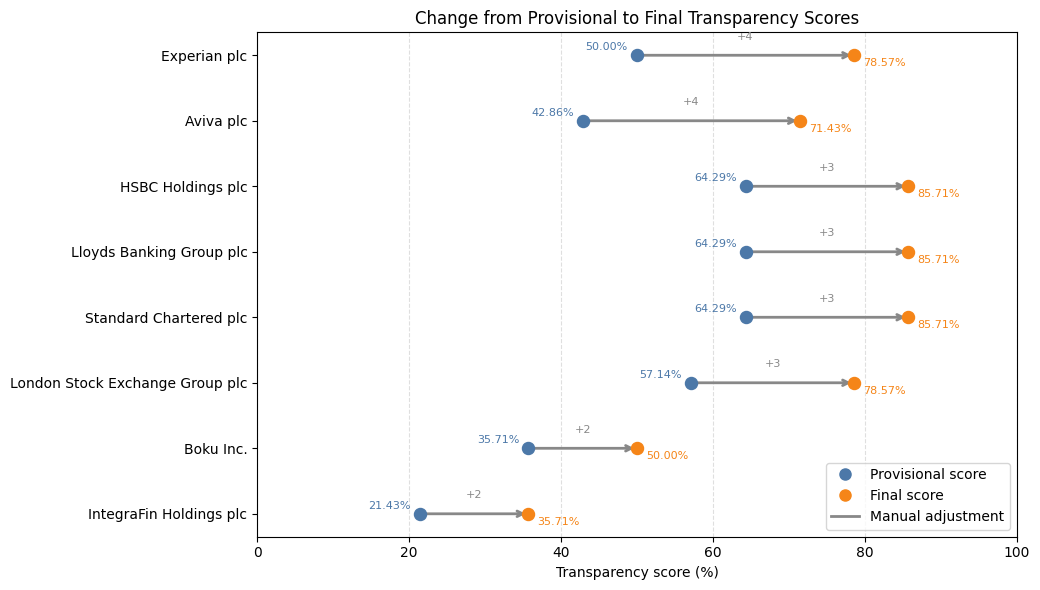

Figure saved to: ..\outputs\figures\adjusted_companies_score_changes.png


In [10]:
from matplotlib.lines import Line2D

adjusted_plot = adjusted_companies[
    [
        "company_name",
        "score_percentage",
        "final_score_percentage",
        "score_change"
    ]
].copy()

# Sort so the largest increases appear first
adjusted_plot = adjusted_plot.sort_values(
    by=["score_change", "final_score_percentage"],
    ascending=[False, False]
).reset_index(drop=True)

adjusted_change_figure_file = figures_folder / "adjusted_companies_score_changes.png"

fig, ax = plt.subplots(figsize=(10.5, 6))

y_positions = np.arange(len(adjusted_plot))

provisional_colour = "#4C78A8"
final_colour = "#F58518"
arrow_colour = "#888888"

for y, (_, row) in zip(y_positions, adjusted_plot.iterrows()):
    start = row["score_percentage"]
    end = row["final_score_percentage"]

    # connecting arrow from provisional to final
    ax.annotate(
        "",
        xy=(end, y),
        xytext=(start, y),
        arrowprops=dict(arrowstyle="->", lw=2, color=arrow_colour)
    )

    # provisional score point
    ax.scatter(
        start, y,
        s=75,
        color=provisional_colour,
        zorder=3
    )

    # final score point
    ax.scatter(
        end, y,
        s=75,
        color=final_colour,
        zorder=3
    )

    # provisional score label
    ax.text(
        start - 1.2,
        y - 0.12,
        f"{start:.2f}%",
        ha="right",
        va="center",
        fontsize=8,
        color=provisional_colour
    )

    # final score label
    ax.text(
        end + 1.2,
        y + 0.12,
        f"{end:.2f}%",
        ha="left",
        va="center",
        fontsize=8,
        color=final_colour
    )

    # score change label
    ax.text(
        (start + end) / 2,
        y - 0.28,
        f"+{row['score_change']:.0f}",
        ha="center",
        va="center",
        fontsize=8,
        color=arrow_colour
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(adjusted_plot["company_name"])
ax.invert_yaxis()

ax.set_xlabel("Transparency score (%)")
ax.set_title("Change from Provisional to Final Transparency Scores")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4)

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=provisional_colour, markeredgecolor=provisional_colour,
           markersize=8, label='Provisional score'),
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=final_colour, markeredgecolor=final_colour,
           markersize=8, label='Final score'),
    Line2D([0], [0], color=arrow_colour, lw=2, label='Manual adjustment')
]

ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()

fig.savefig(
    adjusted_change_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", adjusted_change_figure_file)

Manual validation raised the scores of all eight adjusted firms. Experian and Aviva recorded the largest increases, while the other adjusted firms also moved upward by two to three points. No firm experienced a downward revision.

## 4. Final AI transparency ranking

In [11]:
# Preparing a final ranking table for analysis and reporting

ranking_table = final_ranking[
    [
        "final_rank",
        "company_id",
        "company_name",
        "final_score",
        "final_score_percentage",
        "score_change",
        "rank_change"
    ]
].copy()

ranking_table = ranking_table.rename(
    columns={
        "final_rank": "rank",
        "final_score": "transparency_score",
        "final_score_percentage": "transparency_percentage",
        "score_change": "manual_score_adjustment",
        "rank_change": "ranking_change"
    }
)

ranking_table = ranking_table.sort_values(
    ["rank", "company_name"],
    ascending=[True, True]
).reset_index(drop=True)

ranking_table

,rank,company_id,company_name,transparency_score,transparency_percentage,manual_score_adjustment,ranking_change
0,1,004,NatWest Group plc,13.0,92.86,0.0,0
1,2,001,Barclays plc,12.0,85.71,0.0,0
2,2,002,HSBC Holdings plc,12.0,85.71,3.0,2
3,2,003,Lloyds Banking Group plc,12.0,85.71,3.0,2
4,2,005,Standard Chartered plc,12.0,85.71,3.0,2
5,3,009,Admiral Group plc,11.0,78.57,0.0,0
6,3,020,Experian plc,11.0,78.57,4.0,3
7,3,019,London Stock Exchange Group plc,11.0,78.57,3.0,2
8,4,006,Aviva plc,10.0,71.43,4.0,3
9,5,016,Funding Circle Holdings plc,9.0,64.29,0.0,-1


NatWest recorded the highest score at 92.86%, while CMC Markets ranked lowest at 7.14%. The wide gap indicates uneven levels of AI disclosure across the sample.

In [12]:
# Saving the final ranking table for use in the dissertation

ranking_output_file = results_folder / "final_ai_transparency_ranking.csv"

ranking_table.to_csv(
    ranking_output_file,
    index=False
)

print("Ranking table saved to:", ranking_output_file)
print("Rows saved:", len(ranking_table))

Ranking table saved to: ..\outputs\results\final_ai_transparency_ranking.csv
Rows saved: 20


## 5. Visualising the final transparency rankings

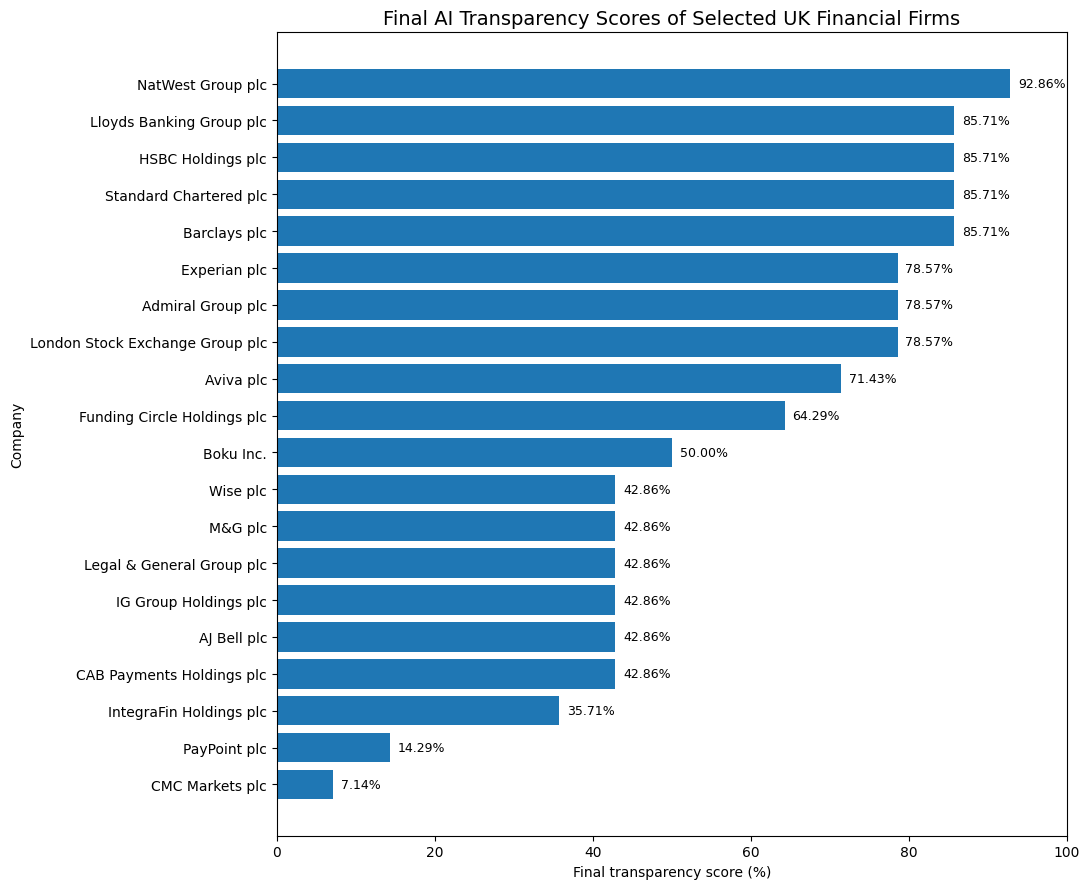

Figure saved to: ..\outputs\figures\final_ai_transparency_ranking.png


In [13]:
# Creating a horizontal bar chart of final transparency percentages

plot_data = final_ranking.sort_values(
    "final_score_percentage",
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    plot_data["company_name"],
    plot_data["final_score_percentage"]
)

# Adding percentage labels to the bars
for bar, percentage in zip(
    bars,
    plot_data["final_score_percentage"]
):
    ax.text(
        percentage + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.2f}%",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Final AI Transparency Scores of Selected UK Financial Firms",
    fontsize=14
)
ax.set_xlabel("Final transparency score (%)")
ax.set_ylabel("Company")
ax.set_xlim(0, 100)

plt.tight_layout()

ranking_figure_file = (
    figures_folder / "final_ai_transparency_ranking.png"
)

fig.savefig(
    ranking_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", ranking_figure_file)

## 6. Distribution of final transparency scores

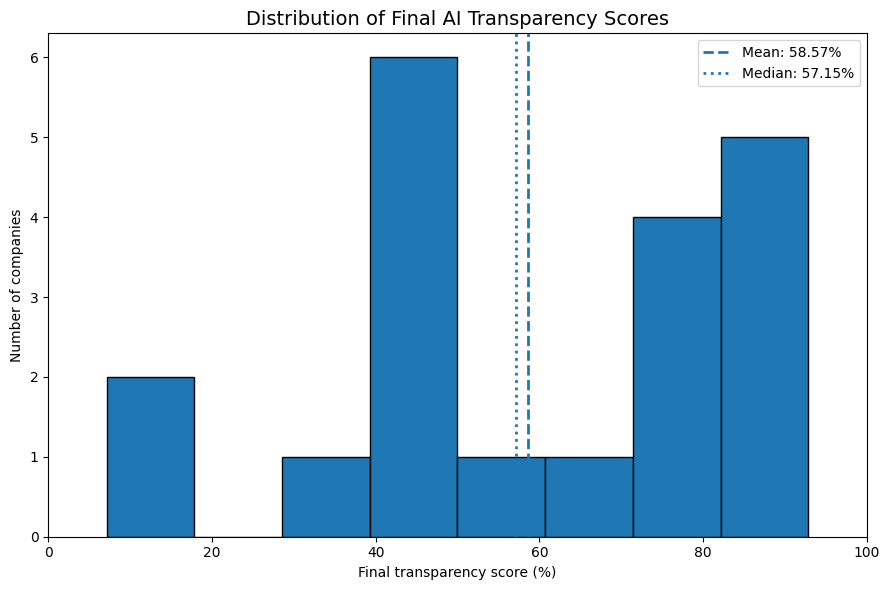

Figure saved to: ..\outputs\figures\final_score_distribution.png


In [14]:
# Visualising the distribution of final transparency percentages

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    final_ranking["final_score_percentage"],
    bins=8,
    edgecolor="black"
)

# Adding mean and median reference lines
mean_score = final_ranking["final_score_percentage"].mean()
median_score = final_ranking["final_score_percentage"].median()

ax.axvline(
    mean_score,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_score:.2f}%"
)

ax.axvline(
    median_score,
    linestyle=":",
    linewidth=2,
    label=f"Median: {median_score:.2f}%"
)

ax.set_title(
    "Distribution of Final AI Transparency Scores",
    fontsize=14
)
ax.set_xlabel("Final transparency score (%)")
ax.set_ylabel("Number of companies")
ax.set_xlim(0, 100)
ax.legend()

plt.tight_layout()

distribution_figure_file = (
    figures_folder / "final_score_distribution.png"
)

fig.savefig(
    distribution_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", distribution_figure_file)

Scores were concentrated around the limited and high transparency ranges, with fewer firms positioned near the middle. This suggests a noticeable divide in disclosure quality.

## 7. Transparency performance groups

In [15]:
# Classifying companies into transparency-performance groups

def classify_transparency(percentage):
    if percentage >= 75:
        return "High transparency"
    elif percentage >= 50:
        return "Moderate transparency"
    elif percentage >= 25:
        return "Limited transparency"
    else:
        return "Low transparency"


analysis_data["transparency_group"] = (
    analysis_data["final_score_percentage"]
    .apply(classify_transparency)
)

group_order = [
    "High transparency",
    "Moderate transparency",
    "Limited transparency",
    "Low transparency"
]

transparency_group_summary = (
    analysis_data["transparency_group"]
    .value_counts()
    .reindex(group_order, fill_value=0)
    .rename_axis("transparency_group")
    .reset_index(name="number_of_companies")
)

transparency_group_summary["percentage_of_sample"] = (
    transparency_group_summary["number_of_companies"]
    / len(analysis_data)
    * 100
).round(2)

transparency_group_summary

,transparency_group,number_of_companies,percentage_of_sample
0,High transparency,8,40.0
1,Moderate transparency,3,15.0
2,Limited transparency,7,35.0
3,Low transparency,2,10.0


Eight firms were classified as high transparency and seven as limited transparency. Together, the limited and low groups represented 45% of the sample, showing that weaker disclosure remained common.

### 7.1 Distribution of firms across transparency groups

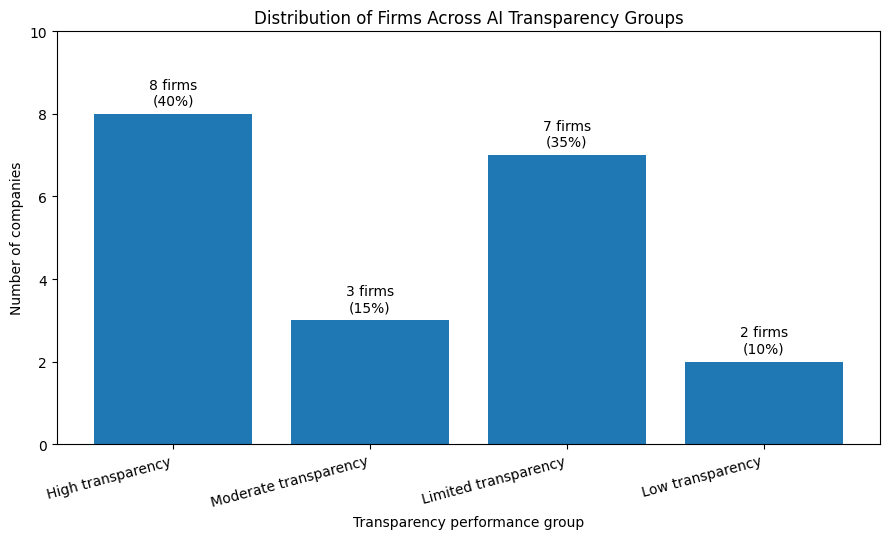

Figure saved to: ..\outputs\figures\transparency_performance_groups.png


In [16]:
# Visualising the number of companies in each transparency-performance group

transparency_group_figure_file = (
    figures_folder / "transparency_performance_groups.png"
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    transparency_group_summary["transparency_group"],
    transparency_group_summary["number_of_companies"]
)

# Adding company-count and sample-percentage labels
for bar, company_count, sample_percentage in zip(
    bars,
    transparency_group_summary["number_of_companies"],
    transparency_group_summary["percentage_of_sample"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{company_count} firms\n({sample_percentage:.0f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Distribution of Firms Across AI Transparency Groups")
ax.set_xlabel("Transparency performance group")
ax.set_ylabel("Number of companies")
ax.set_ylim(
    0,
    transparency_group_summary["number_of_companies"].max() + 2
)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()

plt.savefig(
    transparency_group_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", transparency_group_figure_file)

### 7.2 Companies within each transparency group

In [17]:
# Creating a table showing the companies within each transparency group

group_membership = analysis_data[
    [
        "transparency_group",
        "final_rank",
        "company_id",
        "company_name",
        "final_score",
        "final_score_percentage",
    ]
].copy()

# Preserving the intended transparency-group order
group_membership["transparency_group"] = pd.Categorical(
    group_membership["transparency_group"],
    categories=group_order,
    ordered=True
)

# Sorting companies by group and final transparency score
group_membership = (
    group_membership
    .sort_values(
        by=[
            "transparency_group",
            "final_score_percentage",
            "company_name",
        ],
        ascending=[True, False, True]
    )
    .reset_index(drop=True)
)

group_membership

,transparency_group,final_rank,company_id,company_name,final_score,final_score_percentage
0,High transparency,1,004,NatWest Group plc,13.0,92.86
1,High transparency,2,001,Barclays plc,12.0,85.71
2,High transparency,2,002,HSBC Holdings plc,12.0,85.71
3,High transparency,2,003,Lloyds Banking Group plc,12.0,85.71
4,High transparency,2,005,Standard Chartered plc,12.0,85.71
5,High transparency,3,009,Admiral Group plc,11.0,78.57
6,High transparency,3,020,Experian plc,11.0,78.57
7,High transparency,3,019,London Stock Exchange Group plc,11.0,78.57
8,Moderate transparency,4,006,Aviva plc,10.0,71.43
9,Moderate transparency,5,016,Funding Circle Holdings plc,9.0,64.29


In [18]:
# Saving the transparency-group membership table

group_membership_file = (
    results_folder / "companies_by_transparency_group.csv"
)

group_membership.to_csv(
    group_membership_file,
    index=False
)

print("Table saved to:", group_membership_file)

Table saved to: ..\outputs\results\companies_by_transparency_group.csv


## 8. Additional Visualizations 
### 8.1 Disclosure volume vs final transparency score

Companies included: 20
Missing disclosure-volume values: 0
Correlation between disclosure mentions and final transparency score: 0.79


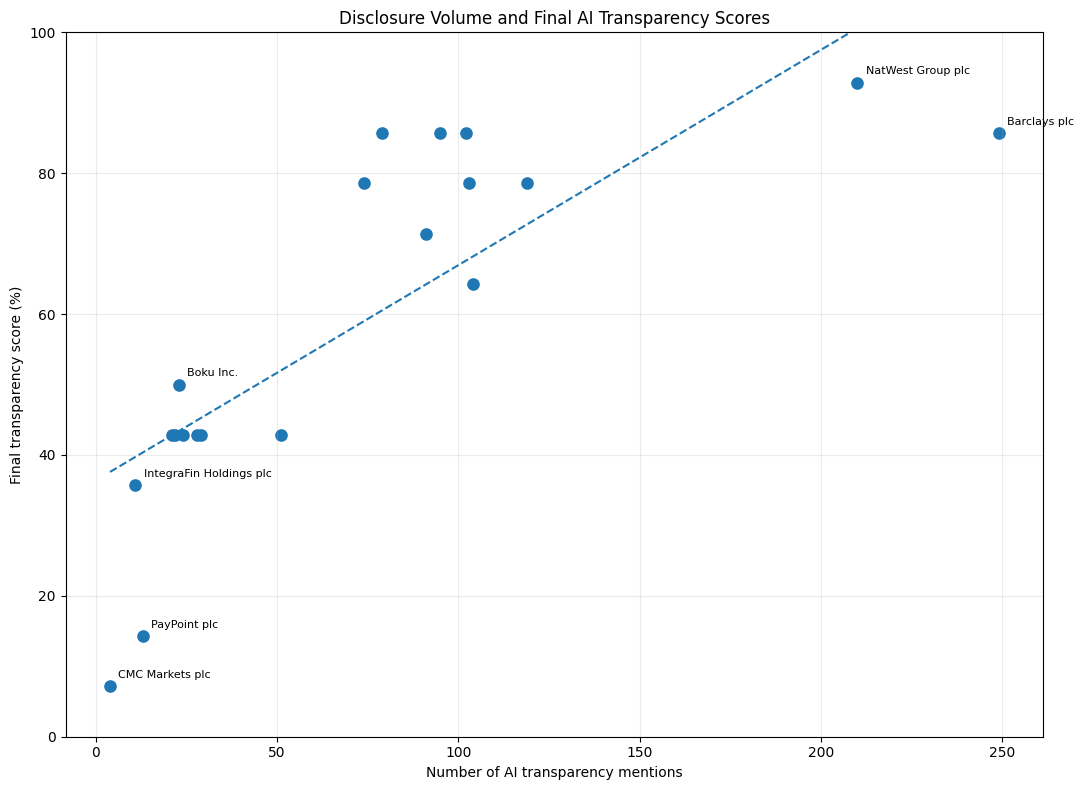

Figure saved to: ..\outputs\figures\disclosure_volume_vs_transparency_score.png


In [20]:
# Preparing data for the disclosure-volume visualisation

mention_column = "total_ai_transparency_mentions"

if mention_column in analysis_data.columns:
    scatter_data = analysis_data[
        [
            "company_id",
            "company_name",
            mention_column,
            "final_score_percentage"
        ]
    ].copy()

else:
    scatter_data = analysis_data[
        [
            "company_id",
            "company_name",
            "final_score_percentage"
        ]
    ].merge(
        manual_review[
            [
                "company_id",
                mention_column
            ]
        ],
        on="company_id",
        how="left",
        validate="one_to_one"
    )

# Converting the chart variables to numeric values
scatter_data[mention_column] = pd.to_numeric(
    scatter_data[mention_column],
    errors="coerce"
)

scatter_data["final_score_percentage"] = pd.to_numeric(
    scatter_data["final_score_percentage"],
    errors="coerce"
)

# Removing any incomplete observations
scatter_data = scatter_data.dropna(
    subset=[
        mention_column,
        "final_score_percentage"
    ]
).copy()

print("Companies included:", len(scatter_data))
print(
    "Missing disclosure-volume values:",
    scatter_data[mention_column].isna().sum()
)

# Calculating the correlation
disclosure_score_correlation = scatter_data[mention_column].corr(
    scatter_data["final_score_percentage"]
)

print(
    "Correlation between disclosure mentions and "
    f"final transparency score: {disclosure_score_correlation:.2f}"
)

# Creating the scatter plot
fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    scatter_data[mention_column],
    scatter_data["final_score_percentage"],
    s=65
)

# Creating the linear trend line
x_values = scatter_data[mention_column]
y_values = scatter_data["final_score_percentage"]

trend_slope, trend_intercept = np.polyfit(
    x_values,
    y_values,
    1
)

trend_x = np.linspace(
    x_values.min(),
    x_values.max(),
    100
)

trend_y = (
    trend_slope * trend_x
    + trend_intercept
)

ax.plot(
    trend_x,
    trend_y,
    linestyle="--",
    linewidth=1.5
)

# Labelling selected firms only
companies_to_label = [
    "NatWest Group plc",
    "Barclays plc",
    "Boku Inc.",
    "IntegraFin Holdings plc",
    "PayPoint plc",
    "CMC Markets plc"
]

for _, row in scatter_data.iterrows():
    if row["company_name"] in companies_to_label:
        ax.annotate(
            row["company_name"],
            (
                row[mention_column],
                row["final_score_percentage"]
            ),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8
        )

ax.set_title(
    "Disclosure Volume and Final AI Transparency Scores"
)

ax.set_xlabel(
    "Number of AI transparency mentions"
)

ax.set_ylabel(
    "Final transparency score (%)"
)

ax.set_ylim(0, 100)
ax.margins(x=0.05)
ax.grid(alpha=0.25)

plt.tight_layout()

# Saving the completed figure
disclosure_scatter_file = (
    figures_folder
    / "disclosure_volume_vs_transparency_score.png"
)

fig.savefig(
    disclosure_scatter_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", disclosure_scatter_file)

With a correlation of 0.79, disclosure volume and the final transparency score were highly correlated. Barclays scored lower than NatWest despite having the most mentions of AI, whereas a handful financial companies received comparatively high tranparency ratings with less disclosures. This suggests that while disclosure frequency had an impact on transparency performance, information quality and relevance also had a significant role.

In [21]:
# Saving the complete dataset used in the results analysis

analysis_data_file = results_folder / "final_analysis_dataset.csv"

analysis_data.to_csv(
    analysis_data_file,
    index=False
)

print("Analysis dataset saved to:", analysis_data_file)
print("Rows saved:", len(analysis_data))

Analysis dataset saved to: ..\outputs\results\final_analysis_dataset.csv
Rows saved: 20


In [22]:
# Saving descriptive statistics and transparency-group summaries

descriptive_statistics_file = (
    results_folder / "descriptive_statistics.csv"
)

transparency_group_summary_file = (
    results_folder / "transparency_group_summary.csv"
)

score_summary.to_csv(
    descriptive_statistics_file
)

transparency_group_summary.to_csv(
    transparency_group_summary_file,
    index=False
)

print("Descriptive statistics saved to:", descriptive_statistics_file)
print("Transparency-group summary saved to:", transparency_group_summary_file)

Descriptive statistics saved to: ..\outputs\results\descriptive_statistics.csv
Transparency-group summary saved to: ..\outputs\results\transparency_group_summary.csv


In [23]:
# Saving the table of manually adjusted companies

adjusted_companies_file = (
    results_folder / "manually_adjusted_companies.csv"
)

adjusted_companies.to_csv(
    adjusted_companies_file,
    index=False
)

print("Adjusted-company table saved to:", adjusted_companies_file)

Adjusted-company table saved to: ..\outputs\results\manually_adjusted_companies.csv
